In [8]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

from ciim.src.common import save_dir, base_dir, plots_dir, datasets_e, datasets_a, datasets_all, cell_types, surrogate_names, colors_blind, palette_cell_types, palette_datasets, palette_datasets_pretty, palette_genders, palette_minor_types

plt.rcParams['font.family'] = 'Arial'  # Arial or 'Liberation Sans'
default_font = matplotlib.rcParams['font.family']

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

In [ ]:
from ciim.src.feature_association.helper import get_consensus_net, retrieve_sig_stats 
cell_type = 'CD8T'

# - mask genes
net = get_consensus_net(cell_type=cell_type)
net['target'].nunique()

# Compare perturbations to one another

In [92]:
def retrieve_perturbation_data(name):
    adata = ad.read_h5ad(f'../../task_grn_inference/resources/extended_data/{name}_bulk.h5ad') 
    adata.var_names_make_unique()
    perturbation_type = adata.obs['perturbation_type'].unique()[0]
    print('number of perturbaions: ', adata.obs['perturbation'].nunique())

    # - subset to targets
    adata = adata[:, adata.var_names.isin(net['target'].unique())]
    print(adata.shape)
    # - subset to aging tfs
    from ciim.src.feature_association.helper import retrieve_sig_stats 
    sig_tfs = retrieve_sig_stats(cell_type=cell_type)['tf'].unique()

    adata = adata[(adata.obs['perturbation'].isin(sig_tfs)) | adata.obs['is_control']]
    print(adata)
    available_tfs = adata.obs['perturbation'].unique()
    available_tfs = np.intersect1d(available_tfs, sig_tfs)
    len(available_tfs)
    return adata, perturbation_type, available_tfs


def compare_log2fc_datasets(log2fc1, log2fc2, perturbation_type_1, perturbation_type_2):
    valid_types = {'overexpression', 'knockdown'}
    if perturbation_type_1 not in valid_types:
        raise ValueError(f"Unknown perturbation_type_1: {perturbation_type_1}")
    if perturbation_type_2 not in valid_types:
        raise ValueError(f"Unknown perturbation_type_2: {perturbation_type_2}")

    # Find common genes
    common_genes = log2fc1.var_names.intersection(log2fc2.var_names)

    # Subset both datasets to common genes
    log2fc1 = log2fc1[:, common_genes]
    log2fc2 = log2fc2[:, common_genes]

    # If perturbation types are opposite, flip the second dataset
    # if perturbation_type_1 != perturbation_type_2:
    #     print("Detected opposite perturbation types. Flipping direction of second dataset.")
    #     log2fc2.X = -log2fc2.X

    # Map perturbations to index for each dataset
    perturb_map1 = {p: i for i, p in enumerate(log2fc1.obs['perturbation'])}
    perturb_map2 = {p: i for i, p in enumerate(log2fc2.obs['perturbation'])}

    # Find common perturbations
    common_perts = set(perturb_map1.keys()) & set(perturb_map2.keys())

    results = {}

    for pert in sorted(common_perts):
        idx1 = perturb_map1[pert]
        idx2 = perturb_map2[pert]

        vec1 = log2fc1.X[idx1]
        vec2 = log2fc2.X[idx2]

        if np.all(np.isnan(vec1)) or np.all(np.isnan(vec2)):
            corr, pval = np.nan, np.nan
        else:
            corr, pval = spearmanr(vec1, vec2, nan_policy='omit')

        results[pert] = {'spearman_corr': corr, 'pval': pval}

    return pd.DataFrame.from_dict(results, orient='index')


def plot_log2fc_comparison(log2fc1, log2fc2, perturbations, dataset1_name='Dataset 1', dataset2_name='Dataset 2'):
    # Find common genes
    common_genes = log2fc1.var_names.intersection(log2fc2.var_names)

    # Subset to common genes
    log2fc1 = log2fc1[:, common_genes]
    log2fc2 = log2fc2[:, common_genes]

    # Map perturbation to row index
    idx_map1 = {p: i for i, p in enumerate(log2fc1.obs['perturbation'])}
    idx_map2 = {p: i for i, p in enumerate(log2fc2.obs['perturbation'])}

    for pert in perturbations:
        if pert not in idx_map1 or pert not in idx_map2:
            print(f"Skipping {pert}: not found in both datasets")
            continue

        x = log2fc1.X[idx_map1[pert]]
        y = log2fc2.X[idx_map2[pert]]

        # Drop NaNs
        valid_mask = ~np.isnan(x) & ~np.isnan(y)
        x_valid = x[valid_mask]
        y_valid = y[valid_mask]

        if len(x_valid) < 5:
            print(f"Skipping {pert}: not enough valid genes for correlation")
            continue

        corr, _ = spearmanr(x_valid, y_valid)

        # Plot
        plt.figure(figsize=(5.5, 5.5))
        sns.scatterplot(x=x_valid, y=y_valid, alpha=0.5, s=15)
        plt.title(f"{pert} | Spearman ρ = {corr:.2f}")
        plt.xlabel(f"{dataset1_name} log2FC")
        plt.ylabel(f"{dataset2_name} log2FC")
        plt.axhline(0, ls='--', color='gray')
        plt.axvline(0, ls='--', color='gray')
        plt.tight_layout()
        plt.show()

In [ ]:
adata_nak, perturbation_type_nak, available_tfs_nak = retrieve_perturbation_data('nakatake')
adata_rep, perturbation_type_rep, available_tfs_rep = retrieve_perturbation_data('replogle')

        spearman_corr      pval
MYC         -0.110391  0.000072
EOMES        0.088087  0.001554
SREBF2      -0.085959  0.002017
ELF4        -0.084669  0.002357
ETS1         0.084084  0.002527


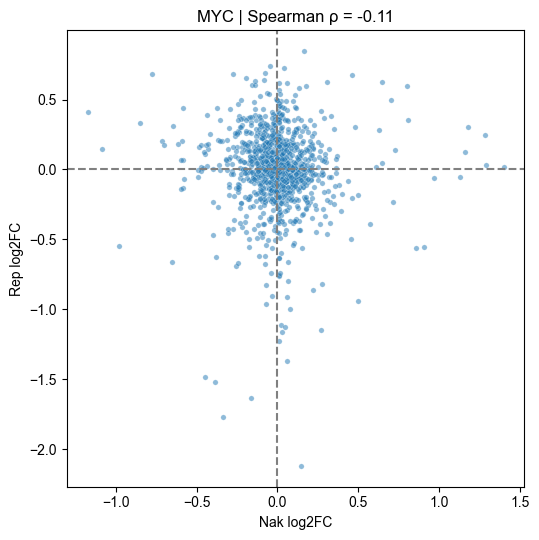

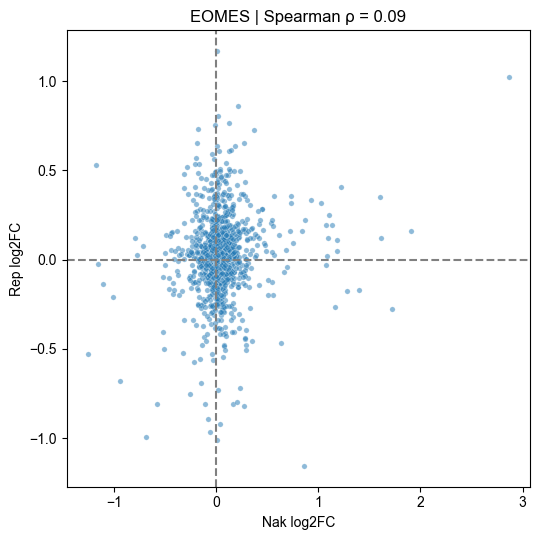

In [109]:
# - TODO: consider the sign of perturbation
from ciim.src.insilico_perturbation.helper import compute_log2fc_vs_ctr
log2fc_nak = compute_log2fc_vs_ctr(adata_nak)
log2fc_rep = compute_log2fc_vs_ctr(adata_rep)


comparison_df = compare_log2fc_datasets(log2fc_nak, log2fc_rep, perturbation_type_nak, perturbation_type_rep).sort_values('spearman_corr', ascending=False, key=abs)
print(comparison_df.head(5))
plot_log2fc_comparison(log2fc_nak, log2fc_rep, comparison_df.index[0:2], dataset1_name='Nak', dataset2_name='Rep')

# Compare experiment to simulated 

In [6]:
import numpy as np
import pandas as pd
import anndata as ad

# Assume adata is your original AnnData object
# and it contains layer 'X_norm'

# Get gene names and perturbation labels
genes = adata.var_names
perturbations = adata.obs['perturbation'].unique()
control_mask = adata.obs['is_control']

# Compute mean expression for control
ctrl_mean = adata[control_mask].layers['X_norm'].mean(axis=0) # instead of this: define a distribution of pairwise ctr-pertubed log2fc

# Prepare log2FC matrix: rows = perturbations, cols = genes
log2fc_matrix = []

pert_names = []

for pert in perturbations:
    if pert == 'CTRL':
        continue
    pert_mask = adata.obs['perturbation'] == pert
    if pert_mask.sum() == 0:
        continue
    pert_mean = adata[pert_mask].layers['X_norm'].mean(axis=0)

    # Avoid division by zero: add small constant
    log2fc = np.log2((pert_mean + 1e-6) / (ctrl_mean + 1e-6)) #TODO: check how we do this in simulation
    log2fc_matrix.append(log2fc)
    pert_names.append(pert)

# Convert to AnnData object
log2fc_adata = ad.AnnData(
    X=np.vstack(log2fc_matrix),
    obs=pd.DataFrame(index=pert_names),
    var=pd.DataFrame(index=genes)
)
log2fc_adata.obs['perturbation'] = pert_names

In [8]:
log2fc_adata

AnnData object with n_obs × n_vars = 42 × 2029
    obs: 'perturbation'

In [18]:
from ciim.src.feature_association.helper import retrieve_feature_data, get_consensus_net
from ciim.src.utils.util import get_genesets
adata_dict = {
        (ds, ct): retrieve_feature_data(dataset=ds, cell_type=ct, smoothened=True, feature_type='gene_expression')
        for ct in ['CD8T']
        for ds in datasets_all
    }
net_dict = {
    ct: get_consensus_net(datasets=datasets_all, cell_type=ct)
    for ct in ['CD8T']
}
pathways = get_genesets()

In [ ]:
import numpy as np
import anndata as ad
from scipy.stats import spearmanr

dataset = 'data1'  # TODO: make this for all
perturbation_mode = 'overexpression'

def simulated_vs_measured(log2fc_simulated, log2fc):
    # Find common genes and sort to ensure matching order
    common_genes = np.intersect1d(log2fc_simulated.var_names, log2fc.var_names)
    log2fc = log2fc[:, [g in common_genes for g in log2fc.var_names]]
    log2fc_simulated = log2fc_simulated[:, [g in common_genes for g in log2fc_simulated.var_names]]

    # Match the order
    log2fc = log2fc[:, common_genes]
    log2fc_simulated = log2fc_simulated[:, common_genes]

    # Convert to arrays
    X = log2fc.X
    if hasattr(X, 'toarray'):
        X = X.toarray()

    X_s = log2fc_simulated.X
    if hasattr(X_s, 'toarray'):
        X_s = X_s.toarray()

    X_s_mean = X_s.mean(axis=0)
    X_mean = X.mean(axis=0)
   
    # - keep only genes with non-zero mean in simulated data
    mask = X_s_mean!=0
    X_s_mean = X_s_mean[mask]
    X_mean = X_mean[mask]
    
    if hasattr(X_mean, 'A1'):  # if sparse mean result
        X_mean = X_mean.A1
    if hasattr(X_s_mean, 'A1'):
        X_s_mean = X_s_mean.A1

    corr, p = spearmanr(X_mean, X_s_mean)

    return p, corr

# Optionally collect results
results = {}

for tf in ['EOMES']:
    temp_dir = f"{save_dir}/perturbation/temp"
    if True:
        from ciim.src.insilico_perturbation.helper import run_in_silico
        run_in_silico(dataset=dataset, cell_type=cell_type, adata_dict=adata_dict, net_dict=net_dict, pathways=pathways, 
        tfs=[tf], perturbation_mode=perturbation_mode, log2fc_genewise=True,
        temp_dir=temp_dir)
    
    path = f'{temp_dir}/log2fc_gene_wise_{dataset}_{cell_type}_{perturbation_mode}_{tf}.h5ad'
    if not os.path.exists(path):
        print(f"Missing file for TF {tf}, skipping.")
        continue
    log2fc_simulated = ad.read_h5ad(path)
    subset = log2fc_adata[log2fc_adata.obs['perturbation'] == tf]
    p, corr = simulated_vs_measured(log2fc_simulated, subset)
    results[tf] = {'pval': p, 'spearman': corr}
    print(f"{tf}: Spearman {corr:.3f}, p={p:.2e}")

EOMES: Spearman 0.005, p=8.11e-01


# Pathway gene score log2fc comparision between simulated and measured

In [9]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from ciim.src.utils.util import get_genesets

logfc_df_store = []
for perturb_gene in tqdm(adata.obs['perturbation'].unique()):
    if perturb_gene not in sig_tfs:
        print(f"Skipping {perturb_gene} as it is not a significant TF.")
        continue
    # Load canonical gene sets
    hallmark_genesets = get_genesets('hallmark')  # dict of {term: list of genes}

    # Get control and perturb_gene samples
    ctrl_adata = adata[adata.obs['is_control']]
    sox4_adata = adata[(~adata.obs['is_control']) & (adata.obs['perturbation'] == perturb_gene)]

    # Sanity check
    if False:
        print(f"Number of control samples: {ctrl_adata.n_obs}")
        print(f"Number of {perturb_gene} samples: {sox4_adata.n_obs}")
    assert ctrl_adata.n_obs > 0, "No control samples found."
    assert sox4_adata.n_obs > 0, f"No {perturb_gene} samples found for perturbation ."

    # Result container
    logfc_results = {}

    # Iterate over gene sets
    for term, genes in hallmark_genesets.items():
        # Filter genes that exist in adata
        valid_genes = [g for g in genes if g in adata.var_names]
        if not valid_genes:
            continue

        # Compute mean gene scores per sample for the current term
        ctrl_scores = ctrl_adata[:, valid_genes].X.mean(axis=1).A1 if hasattr(ctrl_adata[:, valid_genes].X, "A1") else ctrl_adata[:, valid_genes].X.mean(axis=1)
        sox4_scores = sox4_adata[:, valid_genes].X.mean(axis=1).A1 if hasattr(sox4_adata[:, valid_genes].X, "A1") else sox4_adata[:, valid_genes].X.mean(axis=1)

        # Compute all pairwise logFCs
        pairwise_logfcs = []
        for cs in ctrl_scores:
            for ss in sox4_scores:
                # add small constant to avoid division by zero or log of 0
                logfc = np.log2((ss + 1e-6) / (cs + 1e-6))
                pairwise_logfcs.append(logfc)

        # Store mean logFC for this term
        logfc_results[term] = np.mean(pairwise_logfcs)

    # Convert to dataframe for easier inspection
    logfc_df = pd.DataFrame.from_dict(logfc_results, orient='index', columns=['mean_log2fc'])
    logfc_df = logfc_df.sort_values('mean_log2fc', ascending=False)
    logfc_df.index.name = 'pathway'
    logfc_df.reset_index(inplace=True)
    # Show top results
    logfc_df['tf'] = perturb_gene
    logfc_df_store.append(logfc_df)
logfc_df = pd.concat(logfc_df_store, ignore_index=True)
logfc_df.head()

  2%|▏         | 1/42 [00:00<00:24,  1.70it/s]

  7%|▋         | 3/42 [00:01<00:22,  1.72it/s]

Skipping CAG-rtTA35-IH as it is not a significant TF.


 17%|█▋        | 7/42 [00:03<00:17,  2.03it/s]

Skipping Emerald as it is not a significant TF.


 90%|█████████ | 38/42 [00:20<00:02,  1.73it/s]

Skipping Control as it is not a significant TF.


100%|██████████| 42/42 [00:22<00:00,  1.86it/s]


,pathway,mean_log2fc,tf
0,Hedgehog Signaling,0.419131,ASCL2
1,KRAS Signaling Up,0.254974,ASCL2
2,Myogenesis,0.215643,ASCL2
3,Epithelial Mesenchymal Transition,0.195322,ASCL2
4,KRAS Signaling Dn,0.193251,ASCL2


In [10]:
score_shift_summary = pd.read_csv(f"{save_dir}/perturbation/single_aging_tf_pathway_score_shift.csv")
age_shift_mean = pd.read_csv(f"{save_dir}/perturbation/single_aging_tf_age_shift_mean.csv")
scores_simulated = score_shift_summary.groupby(['pathway', 'tf'])['gene_score_shift_log2fc'].mean().reset_index(name='mean_log2fc')

In [11]:
if perturbation_type == 'overexpression':
    logfc_df_corrected = logfc_df
elif perturbation_type == 'knockdown':
    logfc_df_corrected = logfc_df.copy()
    logfc_df_corrected['mean_log2fc'] = -logfc_df['mean_log2fc']
else:
    raise ValueError(f"Unknown perturbation type: {perturbation_type}")

In [12]:
logfc_df_merged = logfc_df_corrected.merge(scores_simulated, on=['pathway', 'tf'], how='left', suffixes=('', '_simulated')).dropna()
logfc_df_merged.head()

,pathway,mean_log2fc,tf,mean_log2fc_simulated
1,KRAS Signaling Up,0.254974,ASCL2,0.720165
2,Myogenesis,0.215643,ASCL2,2.011913
3,Epithelial Mesenchymal Transition,0.195322,ASCL2,1.538565
4,KRAS Signaling Dn,0.193251,ASCL2,-1.103666
5,TGF-beta Signaling,0.171835,ASCL2,0.206007


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import pandas as pd

# Step 1: Compute directional agreement
results = []
for tf in logfc_df_merged['tf'].unique():
    df_sub = logfc_df_merged[logfc_df_merged['tf'] == tf]
    col1 = df_sub['mean_log2fc']
    col2 = df_sub['mean_log2fc_simulated']
    
    if len(col1) < 1:
        continue

    # Compute direction match (same sign)
    direction_match = np.sign(col1) == np.sign(col2)
    n_matches = np.sum(direction_match)
    frac_match = np.mean(direction_match)

    results.append({
        'tf': tf,
        'agreement': frac_match,
        'agreement_n': frac_match-.5,
        'n_matches': n_matches,
        'n_terms': len(col1)
    })

agreement_df = pd.DataFrame(results)

array([[<Axes: title={'center': 'agreement_n'}>]], dtype=object)

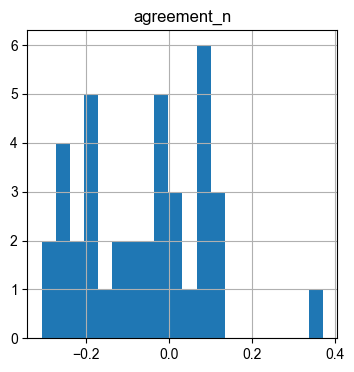

In [14]:
agreement_df.hist('agreement_n', bins=20)

In [15]:
from scipy.stats import ttest_1samp

# Run one-sided one-sample t-test: H0 = mean == 0, H1 = mean > 0
t_stat, pval = ttest_1samp(agreement_df['agreement_n'], popmean=0, alternative='greater')

print(f"One-sample t-test: t = {t_stat:.4f}, p = {pval:.4e}")

One-sample t-test: t = -2.6600, p = 9.9431e-01


# Hierarchical clustering

In [16]:
import ast
import os
import networkx as nx

def extract_functions_and_calls(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        try:
            tree = ast.parse(f.read(), filename=file_path)
        except Exception:
            return {}, nx.DiGraph()

    defined_funcs = set()
    call_graph = nx.DiGraph()

    class Analyzer(ast.NodeVisitor):
        def __init__(self):
            self.current_func = None

        def visit_FunctionDef(self, node):
            func_name = node.name
            defined_funcs.add(func_name)
            self.current_func = func_name
            call_graph.add_node(func_name)
            self.generic_visit(node)

        def visit_Call(self, node):
            if self.current_func is None:
                return

            if isinstance(node.func, ast.Call) and isinstance(node.func.func, ast.Name):
                if node.func.args and isinstance(node.func.args[0], ast.Name):
                    callee = node.func.args[0].id
                    call_graph.add_edge(self.current_func, callee)

            elif isinstance(node.func, ast.Name):
                callee = node.func.id
                call_graph.add_edge(self.current_func, callee)

            self.generic_visit(node)

    Analyzer().visit(tree)
    return defined_funcs, call_graph

def scan_directory(src_dir):
    all_defined = set()
    full_graph = nx.DiGraph()

    for root, _, files in os.walk(src_dir):
        for file in files:
            if file.endswith('.py'):
                path = os.path.join(root, file)
                defs, g = extract_functions_and_calls(path)
                all_defined.update(defs)
                full_graph.add_edges_from(g.edges)

    return all_defined, full_graph

def print_call_tree(graph, defined_funcs, func, depth=0, visited=None):
    if visited is None:
        visited = set()
    indent = "  " * depth
    print(f"{indent}- {func}")
    visited.add(func)
    for callee in graph.successors(func):
        if callee in defined_funcs and callee not in visited:
            print_call_tree(graph, defined_funcs, callee, depth + 1, visited)

def list_recursive_defined_call_tree(src_dir, main_function):
    defined_funcs, graph = scan_directory(src_dir)

    if main_function not in graph:
        print(f"Function '{main_function}' not found in graph.")
        return

    print(f"\nCall tree starting from '{main_function}':\n")
    print_call_tree(graph, defined_funcs, main_function)

# Example usage
src_dir = "../src"
main_func = "wrapper_in_silico_perturbation"
list_recursive_defined_call_tree(src_dir, main_func)


Call tree starting from 'wrapper_in_silico_perturbation':

- wrapper_in_silico_perturbation
  - retrieve_feature_data
  - get_consensus_net
    - retrieve_net
  - get_genesets
    - get_hallmark
    - get_essential_hallmark
    - get_opengenes_sets
    - get_essential_genes
  - run_in_silico
    - get_perturbation_slopes
      - compute_tf_slopes
        - compute_slopes
    - perturb_tf_simulation
      - run_simulation
    - compute_age_shift
      - predict_age
        - retrieve_function
        - align_feature_space
    - compute_gene_score_shift
      - calculate_genes_scores
